# B6 (partie 2) — Auto-encodeur PyTorch, entraînement CPU (catégorie `wood`)

## Objectif concret

Entraîner un auto-encodeur convolutif en **PyTorch** sur les images saines de `wood` préparées en
partie 1, calibrer un seuil d'anomalie sur la validation, puis évaluer la détection sur le test
(saines + défauts). Ce notebook exécute l'entraînement sur **CPU** ([`02c-autoencoder-pytorch-gpu.ipynb`](02c-autoencoder-pytorch-gpu.ipynb) reprend exactement le même code sur GPU) —
la comparaison chiffrée CPU vs GPU est faite dans
[`02d-comparaison-frameworks-devices.ipynb`](02d-comparaison-frameworks-devices.ipynb), à partir des
résultats sauvegardés par les deux notebooks.

Ce notebook réutilise sans les ré-expliquer les notions de la partie 1 (préparation des données,
augmentation) — voir
[`01-preparation-donnees-augmentation-wood.ipynb`](01-preparation-donnees-augmentation-wood.ipynb).

## Prérequis

- **Noyau Jupyter** : sélectionner **`Python 3.12 (indusense, PyTorch ROCm)`**
  (`indusense-py312-rocm`), pas le noyau `python3` par défaut.
- Ouvrir depuis la racine du projet `indusense`.


## Architecture (identique en TensorFlow et PyTorch, CPU et GPU)

Auto-encodeur convolutif symétrique à 3 niveaux, entrée/sortie `256×256×3` :

| Bloc | Couches | Canaux |
|---|---|---|
| Encodeur | `Conv 3×3, stride 2` ×3 (+ ReLU) | `3 → 64 → 128 → 256` |
| Goulot d'étranglement | — | `32×32×256` |
| Décodeur | `ConvTranspose 3×3, stride 2` ×3 (+ ReLU, puis Sigmoid en sortie) | `256 → 128 → 64 → 3` |

La sortie `Sigmoid` produit des valeurs dans `[0, 1]`, cohérentes avec la normalisation des images de
la partie 1. La perte est l'**erreur quadratique moyenne (MSE)** entre l'image d'entrée et sa
reconstruction : c'est elle qui, une fois calculée par image sur le test, sert de **score d'anomalie**.

In [1]:
from pathlib import Path
import time

import numpy as np
import torch

PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)

DEVICE = "cpu"
if DEVICE == "cuda":
    assert torch.cuda.is_available(), "GPU ROCm non détecté par PyTorch."
device = torch.device(DEVICE)
print(f'PyTorch {torch.__version__}, device={device}'
      + (f' ({torch.cuda.get_device_name(0)})' if DEVICE == "cuda" else ''))

from indusense.vision.dataset import (
    list_defect_categories, list_image_paths, load_image_batch,
    resolve_category_root, split_train_validation,
)
from indusense.vision.augment import augment_batch, build_augmentation_pipeline
from indusense.vision.autoencoder_torch import ConvAutoencoder, count_trainable_parameters, images_to_tensor, tensor_to_images
from indusense.vision.anomaly import TrainingRun, choose_threshold, evaluate_at_threshold, ranking_metrics, reconstruction_error

CATEGORY = 'wood'
IMAGE_SIZE = 256
BASE_CHANNELS = 64
BATCH_SIZE = 32
EPOCHS = 60
VALIDATION_FRACTION = 0.15
SEED = 42

category_root = resolve_category_root(CATEGORY)
defect_categories = list_defect_categories(category_root)
train_good_paths = list_image_paths(category_root, 'train', 'good')
split = split_train_validation(train_good_paths, validation_fraction=VALIDATION_FRACTION, seed=SEED)

test_good_paths = list_image_paths(category_root, 'test', 'good')
test_defect_paths = {d: list_image_paths(category_root, 'test', d) for d in defect_categories}

print(f'Train (saines, augmentées à chaque époque) : {len(split.train_paths)}')
print(f'Validation (saines, calibration du seuil) : {len(split.validation_paths)}')
print(f'Test sain : {len(test_good_paths)} ; test défauts : {sum(len(p) for p in test_defect_paths.values())}')

PyTorch 2.9.1+rocm7.2.1, device=cpu


Train (saines, augmentées à chaque époque) : 210
Validation (saines, calibration du seuil) : 37
Test sain : 19 ; test défauts : 60


## Charger les images et construire le pipeline d'augmentation

Les images d'entraînement sont chargées **une seule fois** en mémoire (évite de relire le disque à
chaque époque) ; l'augmentation régénère ensuite une version différente à chaque époque via
`indusense.vision.augment.augment_batch`. La validation et le test ne sont jamais augmentés.

In [2]:
train_raw_images = load_image_batch(split.train_paths, IMAGE_SIZE)
validation_images = load_image_batch(split.validation_paths, IMAGE_SIZE)
test_good_images = load_image_batch(test_good_paths, IMAGE_SIZE)
test_defect_images = {d: load_image_batch(paths, IMAGE_SIZE) for d, paths in test_defect_paths.items()}

augmentation_pipeline = build_augmentation_pipeline(seed=SEED)

print(f'train_raw_images: {train_raw_images.shape}')
print(f'validation_images: {validation_images.shape}')
print(f'test_good_images: {test_good_images.shape}')
for defect, images in test_defect_images.items():
    print(f'test_defect_images[{defect}]: {images.shape}')

train_raw_images: (210, 256, 256, 3)
validation_images: (37, 256, 256, 3)
test_good_images: (19, 256, 256, 3)
test_defect_images[color]: (8, 256, 256, 3)
test_defect_images[combined]: (11, 256, 256, 3)
test_defect_images[hole]: (10, 256, 256, 3)
test_defect_images[liquid]: (10, 256, 256, 3)
test_defect_images[scratch]: (21, 256, 256, 3)


In [3]:
torch.manual_seed(SEED)
model = ConvAutoencoder(base_channels=BASE_CHANNELS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

trainable_parameters = count_trainable_parameters(model)
print(model)
print(f'\nParamètres entraînables : {trainable_parameters:,}'.replace(',', ' '))

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)

Paramètres entraînables : 741 379


## Lecture du résultat précédent : le modèle est-il conforme ?

Le modèle compte **741 379** paramètres entraînables (goulot d'étranglement
`32×32×256`). Ce nombre sera comparé à la version TensorFlow dans le notebook de comparaison : une
architecture strictement équivalente doit produire un compte identique.

## Entraîner l'auto-encodeur

Boucle d'entraînement manuelle : à chaque époque, une version augmentée fraîche du train est générée,
mélangée, puis parcourue par lots de `BATCH_SIZE`. Le temps de la **première époque** est mesuré à
part : elle inclut un coût d'initialisation (allocation mémoire, premier appel aux noyaux de calcul —
particulièrement coûteux sur GPU la toute première fois) qui ne reflète pas la vitesse de croisière.

In [4]:
def run_epoch(raw_images, model, optimizer, loss_fn, pipeline, device, batch_size):
    augmented = np.clip(augment_batch(raw_images, pipeline), 0.0, 1.0)
    batch = images_to_tensor(augmented).to(device)
    permutation = torch.randperm(batch.shape[0])
    running_loss = 0.0
    model.train()
    for start in range(0, batch.shape[0], batch_size):
        indices = permutation[start:start + batch_size]
        images = batch[indices]
        optimizer.zero_grad()
        reconstruction = model(images)
        loss = loss_fn(reconstruction, images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.shape[0]
    return running_loss / batch.shape[0]


loss_history = []

first_epoch_started = time.perf_counter()
loss_history.append(run_epoch(train_raw_images, model, optimizer, loss_fn, augmentation_pipeline, device, BATCH_SIZE))
if DEVICE == "cuda":
    torch.cuda.synchronize()
first_epoch_seconds = time.perf_counter() - first_epoch_started

training_started = time.perf_counter()
for epoch in range(1, EPOCHS):
    epoch_loss = run_epoch(train_raw_images, model, optimizer, loss_fn, augmentation_pipeline, device, BATCH_SIZE)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 10 == 0 or epoch == EPOCHS - 1:
        print(f'Époque {epoch + 1:>3}/{EPOCHS} — perte MSE (train) = {epoch_loss:.5f}')
if DEVICE == "cuda":
    torch.cuda.synchronize()
train_seconds = time.perf_counter() - training_started + first_epoch_seconds
steady_state_seconds_per_epoch = (train_seconds - first_epoch_seconds) / (EPOCHS - 1)

print(f'\nPremière époque : {first_epoch_seconds:.3f} s')
print(f'Temps total ({EPOCHS} époques) : {train_seconds:.3f} s')
print(f"Vitesse de croisière (hors 1ère époque) : {steady_state_seconds_per_epoch * 1000:.1f} ms/époque")

Époque  10/60 — perte MSE (train) = 0.00526


Époque  20/60 — perte MSE (train) = 0.00115


Époque  30/60 — perte MSE (train) = 0.00065


Époque  40/60 — perte MSE (train) = 0.00053


Époque  50/60 — perte MSE (train) = 0.00039


Époque  60/60 — perte MSE (train) = 0.00038

Première époque : 3.801 s
Temps total (60 époques) : 211.039 s
Vitesse de croisière (hors 1ère époque) : 3512.5 ms/époque


## Lecture du résultat précédent : l'entraînement a-t-il convergé ?

La perte MSE (train, augmenté) descend de **0,0170** (1ère époque) à **0,00038** (dernière époque), avec un court plateau/rebond entre les époques 5 et 9 (~0,0070 à 0,0080) avant de reprendre sa baisse — probablement un effet de l'augmentation aléatoire produisant, sur quelques époques, un lot de train visuellement plus éloigné de la moyenne. La courbe est ensuite monotone décroissante jusqu'à la fin.

Sur **CPU**, la première époque prend **3,801 s** contre **3512,5 ms** en régime de croisière : le surcoût (facteur 1,1x) reste limité, le CPU ne subissant pas de compilation de noyaux comme le GPU — PyTorch est déjà « chaud » dès l'import. Le temps total des 60 époques est de **211,04 s**.

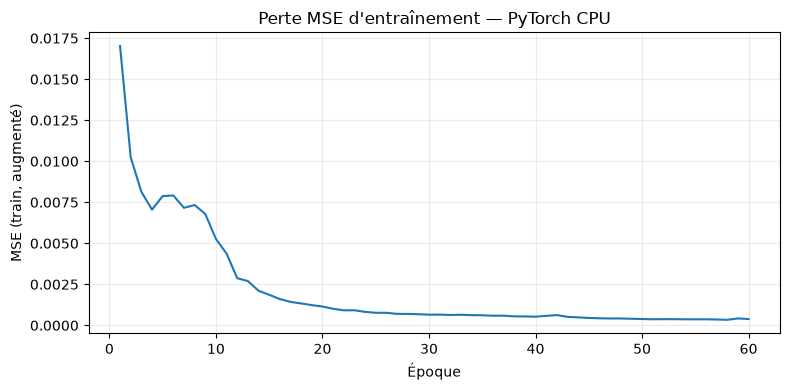

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), loss_history)
ax.set(title=f"Perte MSE d'entraînement — PyTorch {'CPU'}", xlabel='Époque', ylabel='MSE (train, augmenté)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Calibrer le seuil et évaluer la détection d'anomalie

Le modèle passe en mode évaluation (`model.eval()`, désactive tout comportement stochastique). L'erreur
de reconstruction moyenne par image sert de **score d'anomalie**. Le seuil est calibré sur la
validation (saine uniquement) : `moyenne + 3 écarts-types`. Le test combine les images saines
(`label = 0`) et toutes les catégories de défauts (`label = 1`).

In [6]:
@torch.no_grad()
def reconstruct(images_hwc, model, device, batch_size=32):
    model.eval()
    tensor = images_to_tensor(images_hwc)
    outputs = []
    for start in range(0, tensor.shape[0], batch_size):
        batch = tensor[start:start + batch_size].to(device)
        outputs.append(tensor_to_images(model(batch)))
    return np.concatenate(outputs, axis=0)


validation_reconstruction = reconstruct(validation_images, model, device)
validation_errors = reconstruction_error(validation_images, validation_reconstruction)
threshold = choose_threshold(validation_errors, n_std=3.0)

test_images_by_group = {'good': test_good_images, **test_defect_images}
test_errors_by_group = {}
for group_name, images in test_images_by_group.items():
    reconstruction = reconstruct(images, model, device)
    test_errors_by_group[group_name] = reconstruction_error(images, reconstruction)

test_labels = np.concatenate([
    np.zeros(len(test_errors_by_group['good']), dtype=int),
    *[np.ones(len(test_errors_by_group[d]), dtype=int) for d in defect_categories],
])
test_scores = np.concatenate([test_errors_by_group['good']] + [test_errors_by_group[d] for d in defect_categories])

ranking = ranking_metrics(test_labels, test_scores)
threshold_metrics = evaluate_at_threshold(test_labels, test_scores, threshold)
mean_error_by_defect = {group: float(errors.mean()) for group, errors in test_errors_by_group.items()}

from tabulate import tabulate
print(f'Seuil (validation, moyenne + 3 écarts-types) : {threshold:.6f}')
print(f"ROC-AUC test : {ranking['roc_auc']:.4f} ; PR-AUC test : {ranking['pr_auc']:.4f}\n")
print(tabulate(
    [[group, f'{err:.6f}'] for group, err in mean_error_by_defect.items()],
    headers=['Groupe', 'Erreur de reconstruction moyenne'], tablefmt='github',
))
print()
print(tabulate(
    [[threshold_metrics.precision, threshold_metrics.recall, threshold_metrics.f1,
      threshold_metrics.true_positive, threshold_metrics.true_negative,
      threshold_metrics.false_positive, threshold_metrics.false_negative]],
    headers=['Précision', 'Rappel', 'F1', 'VP', 'VN', 'FP', 'FN'], tablefmt='github',
))

Seuil (validation, moyenne + 3 écarts-types) : 0.001056
ROC-AUC test : 0.9561 ; PR-AUC test : 0.9861

| Groupe   |   Erreur de reconstruction moyenne |
|----------|------------------------------------|
| good     |                           0.000338 |
| color    |                           0.000596 |
| combined |                           0.000688 |
| hole     |                           0.000719 |
| liquid   |                           0.000533 |
| scratch  |                           0.000757 |

|   Précision |   Rappel |       F1 |   VP |   VN |   FP |   FN |
|-------------|----------|----------|------|------|------|------|
|           1 |      0.1 | 0.181818 |    6 |   19 |    0 |   54 |


## Lecture du résultat précédent : le seuil détecte-t-il les défauts ?

Le classement est excellent : **ROC-AUC = 0,9561**, **PR-AUC = 0,9861**
(loin au-dessus de la prévalence de base). Mais au seuil calibré (`moyenne + 3 écarts-types` de la
validation, soit **0,001056**), la détection réelle est très différente : **précision
= 1,00**, **rappel = 0,10** — seulement **6**
défauts détectés sur **60**, avec **0**
fausse alerte. Un excellent ROC-AUC/PR-AUC ne garantit donc pas un bon compromis au seuil choisi : ces
deux métriques évaluent le *classement* des scores, indépendamment de tout seuil, tandis que précision
et rappel dépendent entièrement de la règle de décision. Ici, `moyenne + 3 écarts-types` est **trop
conservateur** — une alternative plus proche du rappel recherché (percentile de validation plus bas, ou
seuil optimisant un F-bêta comme en partie 1 sprint 2) détecterait probablement davantage de défauts,
au prix de quelques fausses alertes.

Le détail par catégorie de défaut confirme l'intuition de la partie 1 sur la difficulté visuelle des
défauts : l'erreur moyenne des saines de test est **0,000338**, celle de `liquid`
(**0,000533**) reste la plus proche de cette référence saine — c'est le défaut le plus
discret visuellement en partie 1, et le plus proche du bruit de reconstruction ici aussi. `scratch`
(**0,000757**) et `hole` (**0,000719**) s'en écartent le plus.

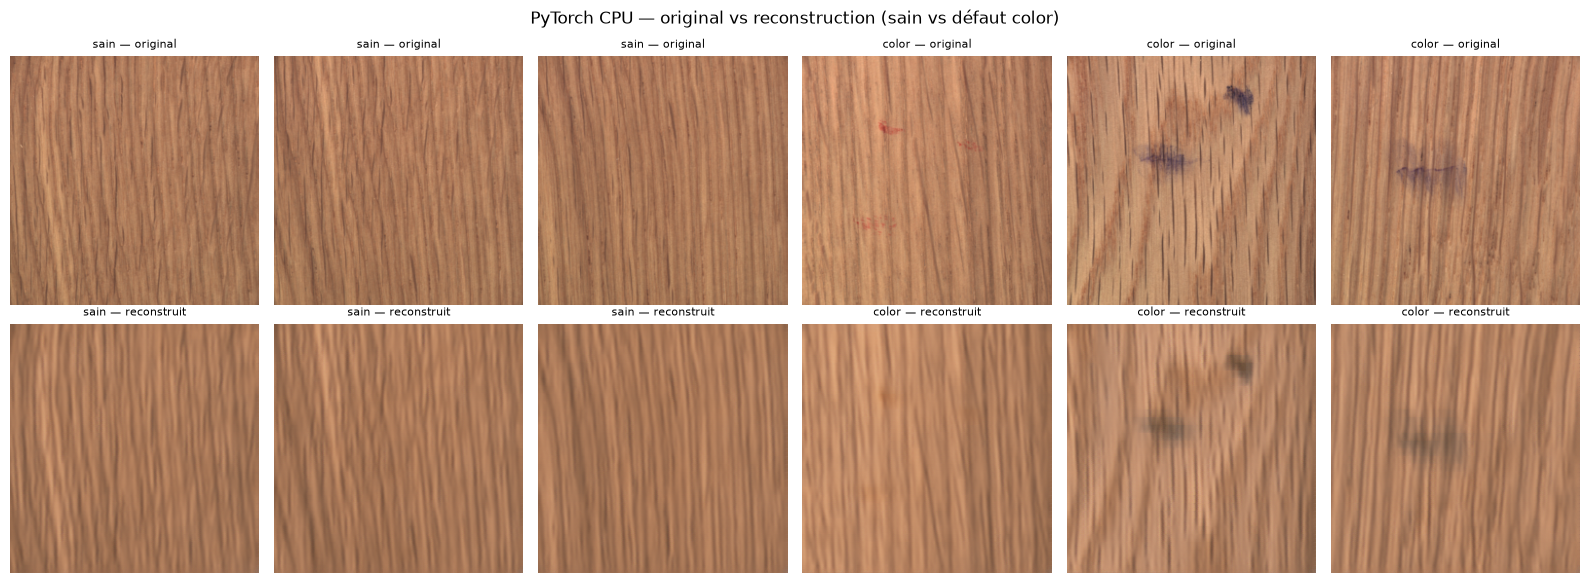

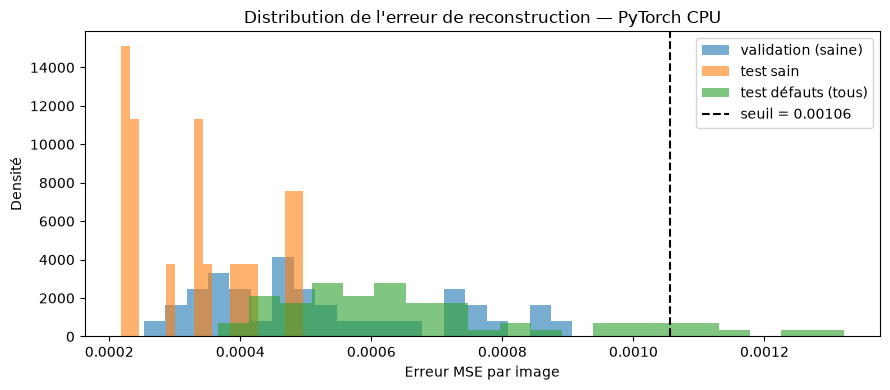

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
sample_good = test_good_images[:3]
sample_good_recon = reconstruct(sample_good, model, device)
sample_defect_name = defect_categories[0]
sample_defect = test_images_by_group[sample_defect_name][:3]
sample_defect_recon = reconstruct(sample_defect, model, device)

for col in range(3):
    axes[0, col].imshow(np.clip(sample_good[col], 0, 1)); axes[0, col].set_title('sain — original', fontsize=8); axes[0, col].axis('off')
    axes[1, col].imshow(np.clip(sample_good_recon[col], 0, 1)); axes[1, col].set_title('sain — reconstruit', fontsize=8); axes[1, col].axis('off')
for col in range(3):
    axes[0, col + 3].imshow(np.clip(sample_defect[col], 0, 1)); axes[0, col + 3].set_title(f'{sample_defect_name} — original', fontsize=8); axes[0, col + 3].axis('off')
    axes[1, col + 3].imshow(np.clip(sample_defect_recon[col], 0, 1)); axes[1, col + 3].set_title(f'{sample_defect_name} — reconstruit', fontsize=8); axes[1, col + 3].axis('off')
fig.suptitle(f'PyTorch {'CPU'} — original vs reconstruction (sain vs défaut {sample_defect_name})')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(validation_errors, bins=20, alpha=0.6, label='validation (saine)', density=True)
ax.hist(test_errors_by_group['good'], bins=20, alpha=0.6, label='test sain', density=True)
all_defect_errors = np.concatenate([test_errors_by_group[d] for d in defect_categories])
ax.hist(all_defect_errors, bins=20, alpha=0.6, label='test défauts (tous)', density=True)
ax.axvline(threshold, color='black', linestyle='--', label=f'seuil = {threshold:.5f}')
ax.set(title=f"Distribution de l'erreur de reconstruction — PyTorch {'CPU'}", xlabel='Erreur MSE par image', ylabel='Densité')
ax.legend()
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : que montrent les reconstructions ?

Les images saines sont reconstruites de façon lisse et fidèle, avec une légère perte de la texture fine
du grain — attendu pour un goulot d'étranglement `32×32×256` qui compresse fortement l'information
spatiale. Sur les échantillons `color` affichés, les petites marques rouges ponctuelles sont largement
« effacées » par la reconstruction (le modèle les traite comme du bruit à lisser, cohérent avec un
entraînement exclusivement sur des saines), alors que les taches plus grandes et diffuses sont
partiellement reproduites (floutées, mais toujours visibles) : le modèle a partiellement généralisé ce
motif plutôt que de le rejeter, ce qui explique une erreur `color` modérée plutôt qu'extrême.

L'histogramme confirme un chevauchement important entre les distributions d'erreur du **test sain** et
du **test défauts** dans la zone `0,0004`–`0,0009`, alors que le seuil (trait pointillé) se situe très
à droite : seule la queue la plus extrême des défauts le dépasse, ce qui explique directement le faible
rappel mesuré ci-dessus.

## Visualiser les détections au seuil retenu (vrais positifs, faux négatifs)

Conseil de la formatrice : au-delà des exemples génériques sain/défaut ci-dessus (choisis sans lien
avec le seuil), il est plus parlant d'inspecter concrètement **les images que le modèle classe
réellement** au seuil calibré (`moyenne + 3 écarts-types`) :

- **Vrais positifs (VP)** : images de défaut correctement signalées (`label = 1` et score ≥ seuil).
- **Faux négatifs (FN)** : images de défaut classées à tort comme **saines** (`label = 1` et
  score < seuil) — ce sont les défauts qui passeraient inaperçus en production, l'angle mort direct
  du faible rappel mesuré ci-dessus.

Les VP sont triés par score décroissant (détections les plus franches d'abord) ; les FN aussi, par
score décroissant parmi les ratés (les plus proches du seuil — les « presque détectés » — d'abord).

Défauts détectés (vrais positifs) : 6 / 60
Défauts classés sains (faux négatifs) : 54 / 60


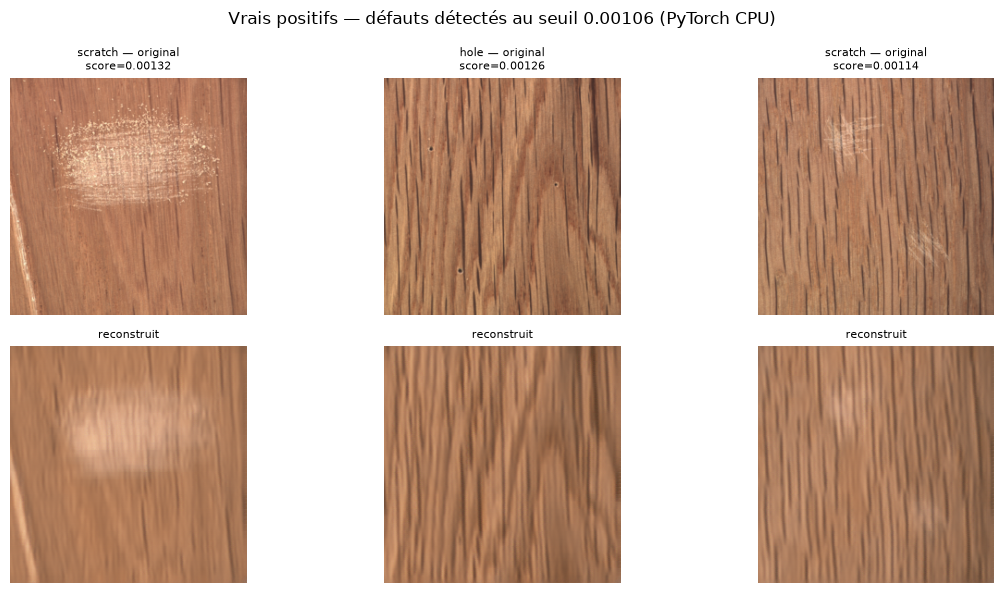

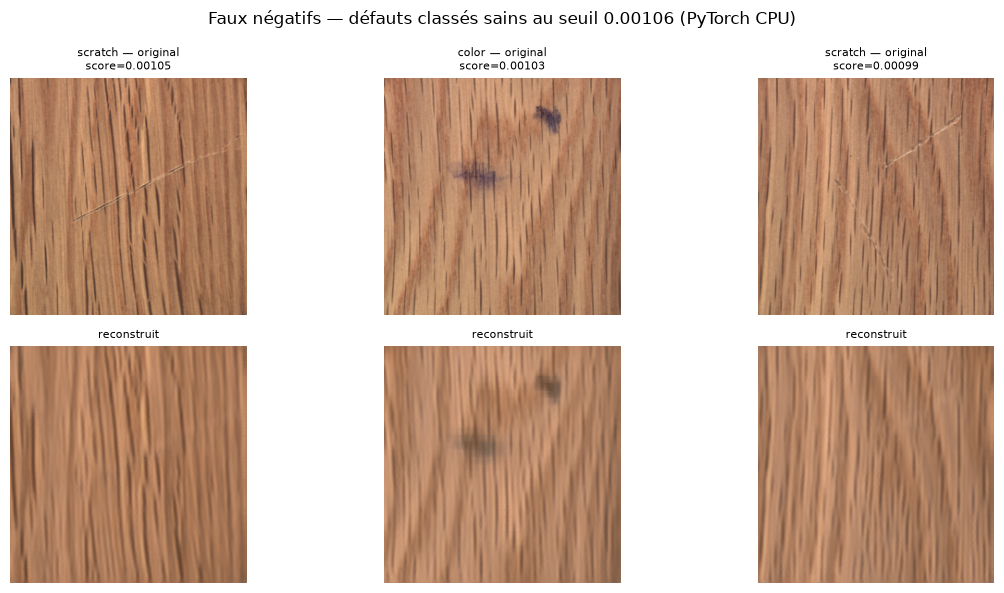

In [8]:
predictions = (test_scores >= threshold).astype(int)
test_group_names = np.array(
    ['good'] * len(test_errors_by_group['good'])
    + [defect for defect in defect_categories for _ in range(len(test_errors_by_group[defect]))]
)
test_images_concat = np.concatenate(
    [test_images_by_group['good']] + [test_images_by_group[d] for d in defect_categories], axis=0
)

true_positive_indices = np.where((test_labels == 1) & (predictions == 1))[0]
false_negative_indices = np.where((test_labels == 1) & (predictions == 0))[0]
true_positive_indices = true_positive_indices[np.argsort(-test_scores[true_positive_indices])][:3]
false_negative_indices = false_negative_indices[np.argsort(-test_scores[false_negative_indices])][:3]

print(f'Défauts détectés (vrais positifs) : {int(((test_labels == 1) & (predictions == 1)).sum())} / {int((test_labels == 1).sum())}')
print(f'Défauts classés sains (faux négatifs) : {int(((test_labels == 1) & (predictions == 0)).sum())} / {int((test_labels == 1).sum())}')


def plot_detections(indices, title):
    if len(indices) == 0:
        print(f'{title} : aucune image (0 cas au seuil retenu).')
        return
    imgs = test_images_concat[indices]
    reconstructed = reconstruct(imgs, model, device)
    fig, axes = plt.subplots(2, len(indices), figsize=(4 * len(indices), 6), squeeze=False)
    for col, idx in enumerate(indices):
        axes[0, col].imshow(np.clip(imgs[col], 0, 1))
        axes[0, col].set_title(f'{test_group_names[idx]} — original\nscore={test_scores[idx]:.5f}', fontsize=8)
        axes[0, col].axis('off')
        axes[1, col].imshow(np.clip(reconstructed[col], 0, 1))
        axes[1, col].set_title('reconstruit', fontsize=8)
        axes[1, col].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_detections(true_positive_indices, f'Vrais positifs — défauts détectés au seuil {threshold:.5f} (PyTorch CPU)')
plot_detections(false_negative_indices, f'Faux négatifs — défauts classés sains au seuil {threshold:.5f} (PyTorch CPU)')

## Lecture du résultat précédent : que montrent ces détections ?

**6** défauts sur 60 sont détectés (vrais positifs) et **54** sont classés à tort comme sains (faux négatifs) — cohérent avec le rappel de 0,10 mesuré ci-dessus. Les vrais positifs affichés sont les 3 défauts au score le plus élevé : ce sont les cas où l'écart visuel entre original et reconstruction est le plus franc, ce qui explique qu'ils dépassent le seuil malgré sa position très conservatrice.

Les faux négatifs affichés sont, à l'inverse, les défauts **les plus proches du seuil parmi les ratés** : leur reconstruction est visuellement presque aussi fidèle que celle d'une image saine, ce qui illustre concrètement pourquoi `moyenne + 3 écarts-types` est une politique trop conservatrice ici — ces défauts existent bien mais produisent une erreur de reconstruction trop proche de celle des saines pour franchir ce seuil précis.

In [9]:
run = TrainingRun(
    framework='pytorch',
    device=DEVICE,
    category=CATEGORY,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    trainable_parameters=trainable_parameters,
    first_epoch_seconds=first_epoch_seconds,
    train_seconds=train_seconds,
    seconds_per_epoch=steady_state_seconds_per_epoch,
    final_train_loss=loss_history[-1],
    validation_error_mean=float(validation_errors.mean()),
    validation_error_std=float(validation_errors.std()),
    threshold=threshold,
    roc_auc=ranking['roc_auc'],
    pr_auc=ranking['pr_auc'],
    metrics_at_threshold=threshold_metrics,
    mean_error_by_defect=mean_error_by_defect,
)
run_path = PROJECT_ROOT / "outputs/deep-learning/pytorch-cpu.json"
run.to_json(run_path)
print(f'Résultats sauvegardés : {run_path}')
print(f'Première époque : {first_epoch_seconds:.3f} s, croisière : {steady_state_seconds_per_epoch*1000:.1f} ms/époque, total : {train_seconds:.3f} s')

Résultats sauvegardés : D:\source\A4U\FormationIA\indusense\outputs\deep-learning\pytorch-cpu.json
Première époque : 3.801 s, croisière : 3512.5 ms/époque, total : 211.039 s


## Synthèse

Entraînement PyTorch sur **CPU** de l'auto-encodeur convolutif (mêmes hyperparamètres et
même architecture que la version TensorFlow et que l'autre device PyTorch). Résultats détaillés
(temps, ROC-AUC, PR-AUC, précision/rappel) dans les cellules ci-dessus, et comparaison consolidée dans
[`02d-comparaison-frameworks-devices.ipynb`](02d-comparaison-frameworks-devices.ipynb).